In [14]:
from langchain_core.messages.utils import trim_messages,count_tokens_approximately
from langgraph.graph import StateGraph, START, MessagesState, END
from langgraph.checkpoint.postgres import PostgresSaver
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver
load_dotenv()

True

In [15]:
llm = ChatGroq(
    model="openai/gpt-oss-120b"
)

In [16]:
MAX_TOKENS = 150

In [17]:
def call_model(state: MessagesState):
    
    # Trim conversation history -> last N messages that fit within the token budget
    messages = trim_messages(
        state["messages"],
        strategy="last",                      
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS
    )

    print('Current Token Count ->', count_tokens_approximately(messages=messages))

    for message in messages:
        print(message.content)

    response = llm.invoke(messages)

    return {"messages": [response]}

In [18]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")
builder.add_edge("call_model", END)

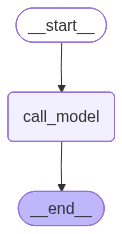

In [19]:
checkpointer = InMemorySaver()
workflow = builder.compile(checkpointer=checkpointer)
workflow

In [20]:
config = {"configurable": {"thread_id": "chat-1"}}

result = workflow.invoke(
    {"messages": [{"role": "user", "content": "Hi, my name is harsh."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 10
Hi, my name is harsh.


'Hello Harsh! Nice to meet you. How can I assist you today?'

In [21]:
result = workflow.invoke(
    {"messages": [{"role": "user", "content": "I am learning LangGraph."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 40
Hi, my name is harsh.
Hello Harsh! Nice to meet you. How can I assist you today?
I am learning LangGraph.


'That’s great! LangGraph is a powerful framework for building composable, state‑driven LLM applications, and there’s a lot you can do with it. Here’s a quick roadmap to help you get started and deepen your understanding:\n\n---\n\n## 1️⃣ Core Concepts at a Glance\n\n| Concept | What It Is | Why It Matters |\n|---------|------------|----------------|\n| **Node** | A single “step” in a graph (e.g., a prompt, a tool call, a data fetch). | Encapsulates a piece of logic that can be reused. |\n| **Edge** | The directed connection between nodes, often conditioned on state. | Determines the flow of execution. |\n| **State** | A mutable dictionary (or Pydantic model) that travels through the graph. | Lets you store intermediate results, track progress, and make decisions. |\n| **Graph** | The full directed‑acyclic (or cyclic) network of nodes/edges. | Represents the whole workflow of your LLM app. |\n| **Checkpoint / Persistence** | Saving the state and current node so you can resume later. | C

In [22]:
result = workflow.invoke(
    {"messages": [{"role": "user", "content": "Can you explain short term memory?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 13
Can you explain short term memory?


'**Short‑term memory (STM)** is a mental system that temporarily holds a limited amount of information in an active, readily accessible state. It’s the “scratch‑pad” of the mind that lets us keep a phone number in mind long enough to dial it, remember the last few words we heard in a conversation, or manipulate a small set of items while solving a problem.\n\nBelow is a concise overview of the key features, underlying mechanisms, and practical implications of short‑term memory.\n\n---\n\n## 1. Core Characteristics\n\n| Feature | Typical Values | What It Means |\n|---------|----------------|---------------|\n| **Capacity** | 5‑9 “chunks” of information (Miller’s classic 7\u202f±\u202f2) | A “chunk” can be a single digit, a word, or a meaningful group of items (e.g., a familiar acronym). |\n| **Duration** | ~15‑30\u202fseconds without rehearsal | Information fades quickly unless actively refreshed (rehearsed) or encoded into long‑term memory. |\n| **Encoding** | Primarily **acoustic/phon

In [23]:
result = workflow.invoke(
    {"messages": [{"role": "user", "content": "What is my name?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 8
What is my name?


'I don’t have any information about your name. If you’d like me to address you a certain way, just let me know!'

In [24]:
for item in workflow.get_state({"configurable": {"thread_id": "chat-1"}}).values['messages']:
    print(item.content)
    print('-'*120)

Hi, my name is harsh.
------------------------------------------------------------------------------------------------------------------------
Hello Harsh! Nice to meet you. How can I assist you today?
------------------------------------------------------------------------------------------------------------------------
I am learning LangGraph.
------------------------------------------------------------------------------------------------------------------------
That’s great! LangGraph is a powerful framework for building composable, state‑driven LLM applications, and there’s a lot you can do with it. Here’s a quick roadmap to help you get started and deepen your understanding:

---

## 1️⃣ Core Concepts at a Glance

| Concept | What It Is | Why It Matters |
|---------|------------|----------------|
| **Node** | A single “step” in a graph (e.g., a prompt, a tool call, a data fetch). | Encapsulates a piece of logic that can be reused. |
| **Edge** | The directed connection between nod